# K-Nearest Neighbours


K nearest neighbors is a simple algorithm that stores all available cases and classifies new cases based on a similarity measure (e.g., distance functions).

Algorithm:
A case is classified by a majority vote of its neighbors, with the case being assigned to the class most common amongst its K nearest neighbors measured by a distance function.

# Most Popular distance Metrics are:

In [ ]:
from IPython.display import Image
Image("img/KNN_similarity.png")

### Reference:

Regressor:

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor

Classifier:

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier

---

## Activity 1: Classification

## Dataset - Universal Bank Dataset

Background:

A relatively young bank is growing rapidly in terms of overall customer acquisition. Majority of these are Liability customers with varying sizes of relationship with the bank. The customer base of Asset customers is quite small, and the bank WANTS to grow	this base rapidly to bring in more loan business. Specifically, it wants to explore ways of converting its liability customers to Personal Loan customers.

A campaign the bank ran for liability customers last year showed a healthy conversion rate of over 9% successes. This has encouraged the Retail Marketing department to devise smarter campaigns with better target marketing.

* Analytics Objective:

Predict whether a given customer accepts his/her personal loan offer based on the Universal Bank dataset. There are a total of 5,000 customers in the data set and 14 variables. A brief description of the 14 variables is given below:

ID: Customer ID

Age: Customer's age in completed year

Experience: # of years of professional experience

Income: Annual income of the customer ($000)

ZIPcode: Home address ZIP code

Family: Family size of the customer

CCAvg: Average monthly credit card spending ($000)

Education: Education level: 1: Undergrad; 2: Graduate; 3: Advanced/Professional

Mortgage: Value of house mortgage, if any ($000)

Securities Acct: Does the customer have a securities account with the bank?

CD Account: Does the customer have a certifcate of deposit (CD) account with the bank?

Online: Does the customer use internet banking facilities?

CreditCard: Does the customer use a credit card issued by the bank?

Personal loan: Did this customer accept the personal loan offered in the last campaign? 1 - yes; 0 - no (target variable)

#### Import all the required packages and classes

In [1]:
import os
import numpy as np
import pandas as pd
import math

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import Imputer

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Read the UnivBank.csv file into a pandas dataframe

In [4]:
bank=pd.read_csv('/content/drive/MyDrive/001--DATA SETS--CSV/UnivBank.csv')
bank

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1.0,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1.0,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0.0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0.0,#,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0.0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0.0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0.0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0.0,0,1,0


In [6]:
bank=pd.read_csv('/content/drive/MyDrive/001--DATA SETS--CSV/UnivBank.csv',na_values=["?","#"])
bank

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0.0,0,1.0,0.0,0,0
1,2,45,19,34,90089,3,1.5,1,0.0,0,1.0,0.0,0,0
2,3,39,15,11,94720,1,1.0,1,0.0,0,0.0,0.0,0,0
3,4,35,9,100,94112,1,2.7,2,0.0,0,0.0,NaN,0,0
4,5,35,8,45,91330,4,1.0,2,0.0,0,0.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0.0,0,0.0,0.0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85.0,0,0.0,0.0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0.0,0,0.0,0.0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0.0,0,0.0,0.0,1,0


#### Display the first 5 records

In [7]:
bank.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0.0,0,1.0,0.0,0,0
1,2,45,19,34,90089,3,1.5,1,0.0,0,1.0,0.0,0,0
2,3,39,15,11,94720,1,1.0,1,0.0,0,0.0,0.0,0,0
3,4,35,9,100,94112,1,2.7,2,0.0,0,0.0,NaN,0,0
4,5,35,8,45,91330,4,1.0,2,0.0,0,0.0,0.0,0,1


#### Display the dimensions, column names and column datatypes

In [8]:
print(bank.shape)

(5000, 14)


In [9]:
print(bank.columns)

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')


In [10]:
print(bank.dtypes)

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage              float64
Personal Loan           int64
Securities Account    float64
CD Account            float64
Online                  int64
CreditCard              int64
dtype: object


#### Check the summary (descriptive statistics)  for all attributes

In [11]:
bank.describe(include='all')

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4998.000000,5000.000000,4998.000000,4999.000000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.521409,0.096000,0.104442,0.060412,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.727873,0.294621,0.305863,0.238273,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Check the unique levels in the target attribute PersonalLoan

In [14]:
print(bank["Personal Loan"].value_counts())

Personal Loan
0    4520
1     480
Name: count, dtype: int64


#### Check the number of unique ZIP Codes present in the dataset

In [16]:
print("The number of Unique ZIP Codes in the bank data set is",bank['ZIP Code'].nunique())
print("\n")
print(bank['ZIP Code'].value_counts())

The number of Unique ZIP Codes in the bank data set is 467


ZIP Code
94720    169
94305    127
95616    116
90095     71
93106     57
        ... 
94970      1
90068      1
90813      1
94404      1
94598      1
Name: count, Length: 467, dtype: int64


#### Remove the unncessary columns (ID and ZipCode)

In [18]:
bank=bank.drop(["ID","ZIP Code"],axis=1)

In [19]:
bank.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0.0,0,1.0,0.0,0,0
1,45,19,34,3,1.5,1,0.0,0,1.0,0.0,0,0
2,39,15,11,1,1.0,1,0.0,0,0.0,0.0,0,0
3,35,9,100,1,2.7,2,0.0,0,0.0,NaN,0,0
4,35,8,45,4,1.0,2,0.0,0,0.0,0.0,0,1


#### Check the count of Education values in each level

In [20]:
print("The number of values in different Education levels:\n")
print(bank['Education'].value_counts())

The number of values in different Education levels:

Education
1    2096
3    1501
2    1403
Name: count, dtype: int64


#### Check the count of Family values in each level

In [21]:
print("The number of values in different Family levels:\n")
print(bank['Family'].value_counts())

The number of values in different Family levels:

Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64


#### Convert the attributes to the right data type based on the dataset description

In [23]:
cat_attr=['Education', 'Family', 'CD Account', 'Online','CreditCard','Securities Account']
for cols in cat_attr :
    bank[cols]=bank[cols].astype('category')

In [24]:
bank.dtypes

,0
Age,int64
Experience,int64
Income,int64
Family,category
CCAvg,float64
Education,category
Mortgage,float64
Personal Loan,int64
Securities Account,category
CD Account,category


#### Creating dummy variables

If we have k levels in a category, then we create k-1 dummy variables as the last one would be redundant.
So we use the parameter drop_first in pd.get_dummies function that drops the first level in each of the category.


In [25]:
bank = pd.get_dummies(columns=cat_attr,data=bank,drop_first=True)

In [26]:
bank.head()

,Age,Experience,Income,CCAvg,Mortgage,Personal Loan,Education_2,Education_3,Family_2,Family_3,Family_4,CD Account_1.0,Online_1,CreditCard_1,Securities Account_1.0
0,25,1,49,1.6,0.0,0,False,False,False,False,True,False,False,False,True
1,45,19,34,1.5,0.0,0,False,False,False,True,False,False,False,False,True
2,39,15,11,1.0,0.0,0,False,False,False,False,False,False,False,False,False
3,35,9,100,2.7,0.0,0,True,False,False,False,False,False,False,False,False
4,35,8,45,1.0,0.0,0,True,False,False,False,True,False,False,True,False


####  Check for missing values

In [27]:
bank.isnull().sum()

,0
Age,0
Experience,0
Income,0
CCAvg,0
Mortgage,2
Personal Loan,0
Education_2,0
Education_3,0
Family_2,0
Family_3,0


#### Split the data into train and test

In [29]:
y=bank["Personal Loan"]
X=bank.drop('Personal Loan', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,stratify=y,random_state=123)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 14)
(1000, 14)
(4000,)
(1000,)


In [31]:
print(y_train.value_counts())
print(y_test.value_counts())

Personal Loan
0    3616
1     384
Name: count, dtype: int64
Personal Loan
0    904
1     96
Name: count, dtype: int64


In [32]:
y_train.value_counts(normalize=True) * 100

,proportion
Personal Loan,
0,90.4
1,9.6


In [33]:
y_test.value_counts(normalize=True) * 100

,proportion
Personal Loan,
0,90.4
1,9.6


#### Split the attributes into numerical and categorical types

In [34]:
num_attr=X_train.select_dtypes(['int64','float64']).columns
num_attr

Index(['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage'], dtype='object')

In [35]:
cat_attr = X_train.select_dtypes('category').columns
cat_attr

Index([], dtype='object')

#### Checking for missing values in train and test dataset

In [36]:
X_train.isnull().sum()

,0
Age,0
Experience,0
Income,0
CCAvg,0
Mortgage,1
Education_2,0
Education_3,0
Family_2,0
Family_3,0
Family_4,0


In [37]:
X_test.isnull().sum()

,0
Age,0
Experience,0
Income,0
CCAvg,0
Mortgage,1
Education_2,0
Education_3,0
Family_2,0
Family_3,0
Family_4,0


#### Imputing missing values with median

In [38]:
imputer = SimpleImputer(strategy='median')
imputer = imputer.fit(X_train[num_attr])

X_train[num_attr] = imputer.transform(X_train[num_attr])
X_test[num_attr] = imputer.transform(X_test[num_attr])

In [39]:
imputer.statistics_

array([45. , 20. , 63.5,  1.5,  0. ])

In [40]:
X_train.isnull().sum()

,0
Age,0
Experience,0
Income,0
CCAvg,0
Mortgage,0
Education_2,0
Education_3,0
Family_2,0
Family_3,0
Family_4,0


In [41]:
X_test.isnull().sum()

,0
Age,0
Experience,0
Income,0
CCAvg,0
Mortgage,0
Education_2,0
Education_3,0
Family_2,0
Family_3,0
Family_4,0


#### Standardize the data (numerical attributes only) - Import StandardScaler


In [42]:
scaler = StandardScaler()
scaler.fit(X_train[num_attr])

StandardScaler()

In [43]:
scaler.mean_

array([45.3095   , 20.0785   , 74.0235   ,  1.9490125, 56.8095   ])

In [44]:
scaler.var_

array([1.29667710e+02, 1.29770338e+02, 2.16360295e+03, 3.11726960e+00,
       1.03160472e+04])

In [45]:
X_train[num_attr]=scaler.transform(X_train[num_attr])
X_test[num_attr]=scaler.transform(X_test[num_attr])

#### Build KNN Classifier Model

In [46]:
model= KNeighborsClassifier(n_neighbors=5,metric="euclidean")
model.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean')

#### Predict on the Test data

In [47]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

#### FIne the accuracy classification score

In [48]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.94


### Finding out the IDEAL K-value for the given dataset

### Method-1

In [49]:
# Creating list of different K values for KNN
myList = list(range(2,12))

# Empty list that will hold cv scores
cv_scores = []

# Perform 5-fold cross validation
for k in myList:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    print("scores=",scores)
    cv_scores.append(scores.mean())
    # print("cv_scores=",cv_scores)

scores= [0.9425 0.935  0.935  0.9475 0.935 ]
scores= [0.95    0.95125 0.9425  0.9575  0.94625]
scores= [0.9375  0.93875 0.93375 0.94125 0.9375 ]
scores= [0.94875 0.94875 0.94375 0.9475  0.94625]
scores= [0.93375 0.93875 0.93375 0.94    0.93125]
scores= [0.94375 0.94625 0.94    0.9425  0.93875]
scores= [0.935   0.93875 0.93    0.94    0.93125]
scores= [0.9375 0.9425 0.9375 0.9425 0.935 ]
scores= [0.93375 0.94    0.93125 0.9375  0.93   ]
scores= [0.93875 0.94125 0.93125 0.93875 0.93375]


In [50]:
cv_scores

[np.float64(0.9390000000000001),
 np.float64(0.9495000000000001),
 np.float64(0.9377500000000001),
 np.float64(0.9470000000000001),
 np.float64(0.9355),
 np.float64(0.9422499999999999),
 np.float64(0.9349999999999999),
 np.float64(0.9390000000000001),
 np.float64(0.9344999999999999),
 np.float64(0.93675)]

In [51]:
# Changing to misclassification error
MCE = [1 - x for x in cv_scores]
# Determining best k
optimal_k = myList[MCE.index(min(MCE))]
print("The optimal number of neighbors is %d" % optimal_k)

The optimal number of neighbors is 3


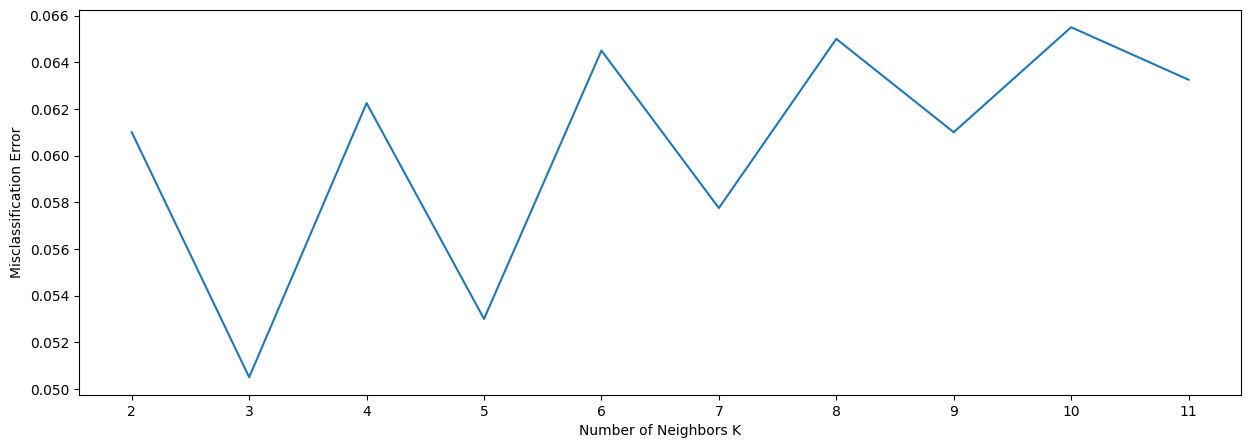

In [52]:
# plot misclassification error vs k
plt.figure(figsize=(15,5))
plt.plot(myList, MCE)

plt.xticks(np.arange(2, 12, 1))
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()

## Model 3

### Method-2: GridSearch Cross validation

The best way to think about hyperparameters is like the settings of an algorithm that can be adjusted to optimize performance.

While model parameters are learned during training — such as the slope and intercept in a linear regression — hyperparameters must be set by the data scientist before training

### K-fold Cross Validation:

#### 1. Use the GridSearchCV

In [53]:
parameters = {'n_neighbors':list(range(2,12))}

clf = GridSearchCV(KNeighborsClassifier(metric="euclidean", n_jobs=-1),
                   parameters,verbose=1, cv=5)

clf.fit(X=X_train, y=y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5,
             estimator=KNeighborsClassifier(metric='euclidean', n_jobs=-1),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
             verbose=1)

In [54]:
knn_model = clf.best_estimator_
knn_model


KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=3)

In [55]:
print (clf.best_score_, clf.best_params_)

0.9495000000000001 {'n_neighbors': 3}


#### 2. Predict on the test data using the best model

In [57]:
y_pred_test=knn_model.predict(X_test)

#### 3. Compute confusion matrix to evaluate the accuracy of the classification

In [58]:
print(confusion_matrix(y_test, y_pred_test))

[[896   8]
 [ 42  54]]


#### 4. Accuracy classification score

In [59]:
print(accuracy_score(y_test,y_pred_test))

0.95


In [60]:
##Learning outcomes

LO110 - Be able to pre-process data as required for kNN model

LO111 - Be able to fit and predict the target value using kNN algorithm in Python for classification problem

LO112 - Be able to compute error metrics based on the output of classification model

LO113 - Be able to implement a function to choose optimum ‘k’

LO114 - Be able to experiment various methods to improve model performance

LO114 - Be able to tune the parameters in the kNN model function with ‘k’, distance metrics, weights